In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class SafeNumeric(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            Xc = X.copy()
            for c in Xc.columns:
                Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
            return Xc.values

        X = np.array(X, dtype=object)
        out = np.empty(X.shape, dtype=float)
        out[:] = np.nan
        for i in range(X.shape[1]):
            out[:, i] = pd.to_numeric(pd.Series(X[:, i]), errors="coerce").values
        return out

In [2]:
import pandas as pd
import joblib

best_model = joblib.load("best_model.pkl")   # your saved RandomForest pipeline/model

X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
X_test  = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_val   = pd.read_csv("y_val.csv").values.ravel()
y_test  = pd.read_csv("y_test.csv").values.ravel()

print("Loaded:", type(best_model))
print(X_train.shape, X_val.shape, X_test.shape)

Loaded: <class 'sklearn.pipeline.Pipeline'>
(588, 208) (148, 208) (185, 208)


In [3]:
#Reliability metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    brier_score_loss
)

In [4]:
from sklearn.calibration import calibration_curve

In [5]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    N = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += np.abs(acc - conf) * (mask.sum() / N)
    return float(ece)

In [6]:
def evaluate(model, X, y, name="model"):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= 0.35).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob),
        "brier": brier_score_loss(y, prob),
        "ece_10bins": expected_calibration_error(y, prob, n_bins=10),
    }

In [7]:
def plot_calibration(model, X, y, title):
    prob = model.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, prob, n_bins=10, strategy="uniform")

    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.show()

In [8]:
val_metrics  = evaluate(best_model, X_val, y_val, "RandomForest — Val")
test_metrics = evaluate(best_model, X_test, y_test, "RandomForest — Test")

val_metrics, test_metrics

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


({'model': 'RandomForest — Val',
  'accuracy': 0.75,
  'precision': 0.582089552238806,
  'recall': 0.8125,
  'f1': 0.6782608695652174,
  'roc_auc': 0.8638541666666666,
  'brier': 0.14059130067567568,
  'ece_10bins': 0.07469594594594593},
 {'model': 'RandomForest — Test',
  'accuracy': 0.772972972972973,
  'precision': 0.6323529411764706,
  'recall': 0.7166666666666667,
  'f1': 0.671875,
  'roc_auc': 0.875,
  'brier': 0.13830385135135131,
  'ece_10bins': 0.0555135135135135})

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


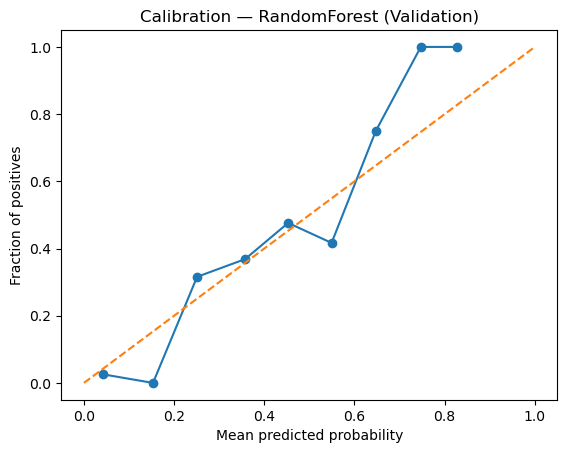

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


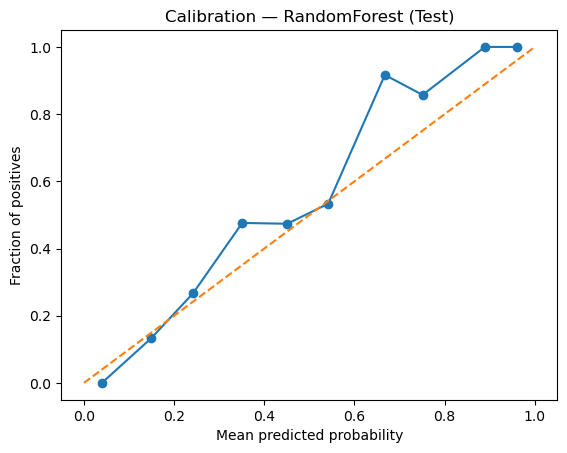

In [9]:
plot_calibration(best_model, X_val, y_val, "Calibration — RandomForest (Validation)")
plot_calibration(best_model, X_test, y_test, "Calibration — RandomForest (Test)")

In [10]:
from sklearn.calibration import CalibratedClassifierCV

cal_sigmoid = CalibratedClassifierCV(best_model, method="sigmoid", cv=3)
cal_isotonic = CalibratedClassifierCV(best_model, method="isotonic", cv=3)

cal_sigmoid.fit(X_train, y_train)
cal_isotonic.fit(X_train, y_train)

evaluate(cal_sigmoid, X_val, y_val, "Calibrated RF (sigmoid) — Val"), evaluate(cal_isotonic, X_val, y_val, "Calibrated RF (isotonic) — Val")

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 8

({'model': 'Calibrated RF (sigmoid) — Val',
  'accuracy': 0.7567567567567568,
  'precision': 0.5967741935483871,
  'recall': 0.7708333333333334,
  'f1': 0.6727272727272727,
  'roc_auc': 0.865,
  'brier': 0.14155264424414069,
  'ece_10bins': 0.11066924491726818},
 {'model': 'Calibrated RF (isotonic) — Val',
  'accuracy': 0.7094594594594594,
  'precision': 0.5362318840579711,
  'recall': 0.7708333333333334,
  'f1': 0.6324786324786325,
  'roc_auc': 0.8626041666666667,
  'brier': 0.14128644166566548,
  'ece_10bins': 0.08991085680016639})

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


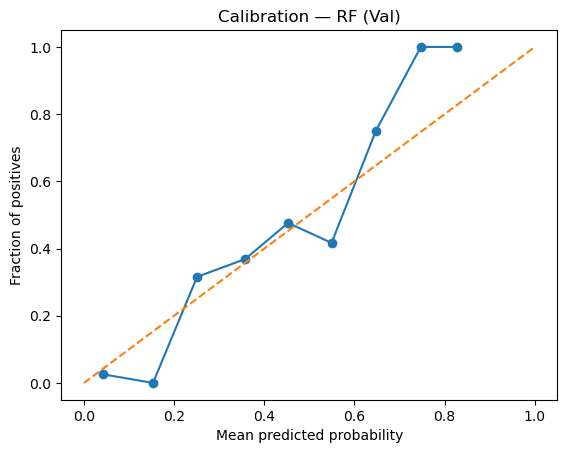

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 9

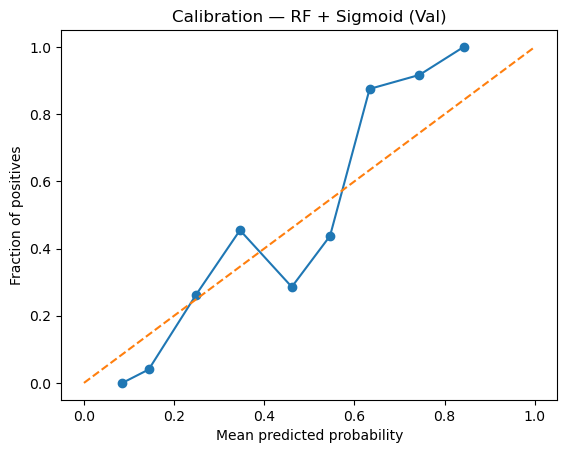

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 9

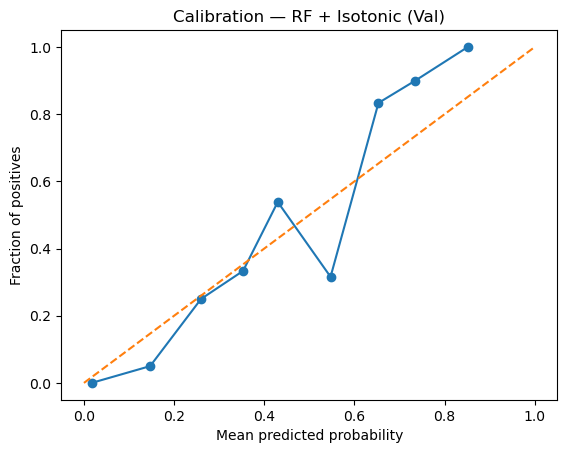

In [11]:
plot_calibration(best_model, X_val, y_val, "Calibration — RF (Val)")
plot_calibration(cal_sigmoid, X_val, y_val, "Calibration — RF + Sigmoid (Val)")
plot_calibration(cal_isotonic, X_val, y_val, "Calibration — RF + Isotonic (Val)")

In [12]:
#Robustness tests

import numpy as np

def inject_missingness(X, missing_rate=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    Xc = X.copy()

    # work on numpy mask but keep dataframe
    mask = rng.random(Xc.shape) < missing_rate
    Xc = Xc.astype("object")  # allows NaN into mixed types safely
    Xc = Xc.mask(mask, other=np.nan)
    return Xc

In [13]:
#run missingness robustness

robust_results = []

for rate in [0.05, 0.10, 0.20]:
    Xv_corrupt = inject_missingness(X_val, missing_rate=rate, random_state=42)
    res = evaluate(best_model, Xv_corrupt, y_val, f"RF — Val missing {int(rate*100)}%")
    robust_results.append(res)

pd.DataFrame(robust_results)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,model,accuracy,precision,recall,f1,roc_auc,brier,ece_10bins
0,RF — Val missing 5%,0.750000,0.584615,0.791667,0.672566,0.859479,0.143647,0.069223
1,RF — Val missing 10%,0.729730,0.560606,0.770833,0.649123,0.853021,0.146875,0.081723
2,RF — Val missing 20%,0.682432,0.507692,0.687500,0.584071,0.809271,0.160660,0.082889


In [14]:
num_cols = X_val.select_dtypes(include=["number"]).columns
len(num_cols), list(num_cols)[:10]

(97,
 ['Diagnosis Age',
  'Age at Diagnosis',
  'Neoplasm Disease Stage American Joint Committee on Cancer Code',
  'Cllularity based on allele frequency',
  'Aneuploidy Score',
  'BCL2 Fish Status',
  'BCL6 Fish Status',
  'B Symptoms at Diagnosis',
  'Censored',
  'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage'])

In [15]:
noise_results = []

for std in [0.05, 0.10, 0.20]:
    Xv_noise = inject_missingness(X_val, missing_rate=rate, random_state=42)
    res = evaluate(best_model, Xv_noise, y_val, f"RF — Val noise {std}")
    noise_results.append(res)

import pandas as pd
pd.DataFrame(noise_results)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,model,accuracy,precision,recall,f1,roc_auc,brier,ece_10bins
0,RF — Val noise 0.05,0.682432,0.507692,0.6875,0.584071,0.809271,0.16066,0.082889
1,RF — Val noise 0.1,0.682432,0.507692,0.6875,0.584071,0.809271,0.16066,0.082889
2,RF — Val noise 0.2,0.682432,0.507692,0.6875,0.584071,0.809271,0.16066,0.082889


In [16]:
#imbalance scenario

from sklearn.utils import resample

def make_imbalanced(X, y, minority_keep=0.5, random_state=42):
    df_tmp = X.copy()
    df_tmp["_y"] = y

    maj = df_tmp[df_tmp["_y"] == 0]
    mino = df_tmp[df_tmp["_y"] == 1]

    mino_down = resample(mino, replace=False, n_samples=max(1, int(len(mino)*minority_keep)), random_state=random_state)
    out = pd.concat([maj, mino_down]).sample(frac=1.0, random_state=random_state)
    y_out = out["_y"].values
    X_out = out.drop(columns=["_y"])
    return X_out, y_out

imb_results = []
for keep in [0.8, 0.5, 0.3]:
    Xi, yi = make_imbalanced(X_val, y_val, minority_keep=keep, random_state=42)
    imb_results.append(evaluate(best_model, Xi, yi, f"RF — Val imbalance keep{keep}"))

pd.DataFrame(imb_results)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,model,accuracy,precision,recall,f1,roc_auc,brier,ece_10bins
0,RF — Val imbalance keep0.8,0.746377,0.525424,0.815789,0.639175,0.871974,0.129038,0.084873
1,RF — Val imbalance keep0.5,0.741935,0.416667,0.833333,0.555556,0.872917,0.114907,0.104919
2,RF — Val imbalance keep0.3,0.728070,0.282051,0.785714,0.415094,0.848214,0.106402,0.144101


In [17]:
#Explainability

#permutation importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=10, random_state=42, scoring="roc_auc"
)

imp = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(20)


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,feature,importance_mean,importance_std
139,Progression Free Status,0.261031,0.043189
205,Patient's Vital Status,0.023271,0.002179
164,Number of Samples Per Patient,0.015437,0.005667
169,Sex,0.006479,0.004748
179,Stage (Highest Recorded),0.006250,0.004184
57,Fraction Genome Altered,0.005604,0.005459
90,IPI,0.001990,0.001027
38,Disease Free (Months),0.001917,0.000740
116,New Neoplasm Event Post Initial Therapy Indicator,0.001250,0.001752
89,In PanCan Pathway Analysis,0.001073,0.000105


In [18]:
#SHAP
!pip install shap -U


In [19]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class SafeNumeric(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            Xc = X.copy()
            for c in Xc.columns:
                Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
            return Xc.values
        X = np.array(X, dtype=object)
        out = np.empty(X.shape, dtype=float)
        out[:] = np.nan
        for i in range(X.shape[1]):
            out[:, i] = pd.to_numeric(pd.Series(X[:, i]), errors="coerce").values
        return out

In [20]:
import joblib
import pandas as pd

best_model = joblib.load("best_model.pkl")

X_val = pd.read_csv("X_val.csv")
y_val = pd.read_csv("y_val.csv").values.ravel()

type(best_model)

sklearn.pipeline.Pipeline

In [21]:
import numpy as np

pre = best_model.named_steps["preprocess"]
rf  = best_model.named_steps["model"]

# Transform X_val
Xv_trans = pre.transform(X_val)

# Grab the fitted transformers
num_transformer = pre.named_transformers_["num"]      # Pipeline
cat_transformer = pre.named_transformers_["cat"]      # Pipeline

# Column lists used at fit time:
num_cols = pre.transformers_[0][2]
cat_cols = pre.transformers_[1][2]

# OneHot feature names
ohe = cat_transformer.named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

# Final combined feature names
feature_names = np.array(list(num_cols) + list(cat_feature_names))

print("Transformed shape:", Xv_trans.shape)
print("Feature names:", len(feature_names))

Transformed shape: (148, 766)
Feature names: 809


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [22]:
type(Xv_trans), getattr(Xv_trans, "dtype", None)

(scipy.sparse._csr.csr_matrix, dtype('float64'))

In [23]:
import numpy as np
from scipy import sparse

# If sparse matrix, convert to dense
if sparse.issparse(Xv_trans):
    Xv_shap = Xv_trans.toarray()
else:
    Xv_shap = np.asarray(Xv_trans)

# Force numeric float (object -> float)
Xv_shap = Xv_shap.astype(np.float64)

print("Xv_shap dtype:", Xv_shap.dtype, "shape:", Xv_shap.shape)

Xv_shap dtype: float64 shape: (148, 766)


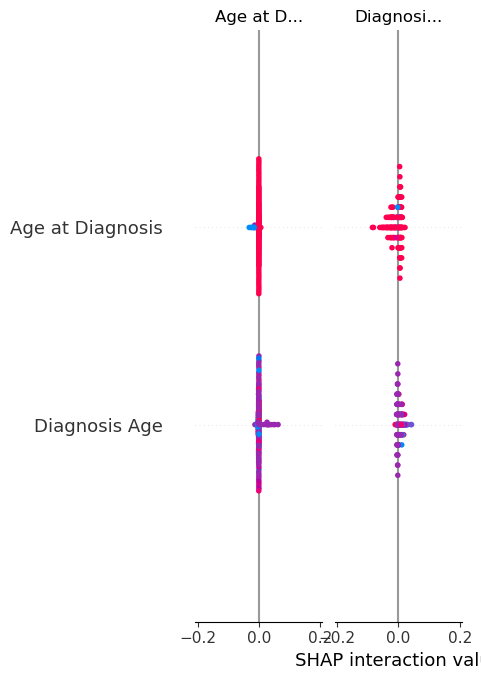

In [24]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(Xv_shap)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, Xv_shap, feature_names=feature_names, show=True)

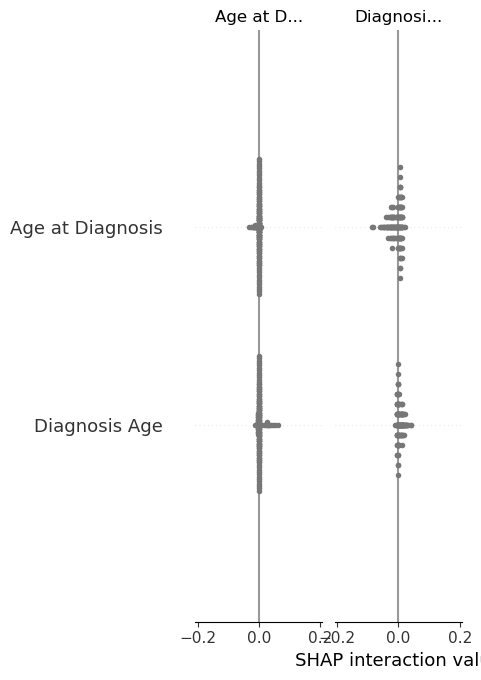

In [25]:
shap.summary_plot(sv, Xv_trans, feature_names=feature_names, show=True)

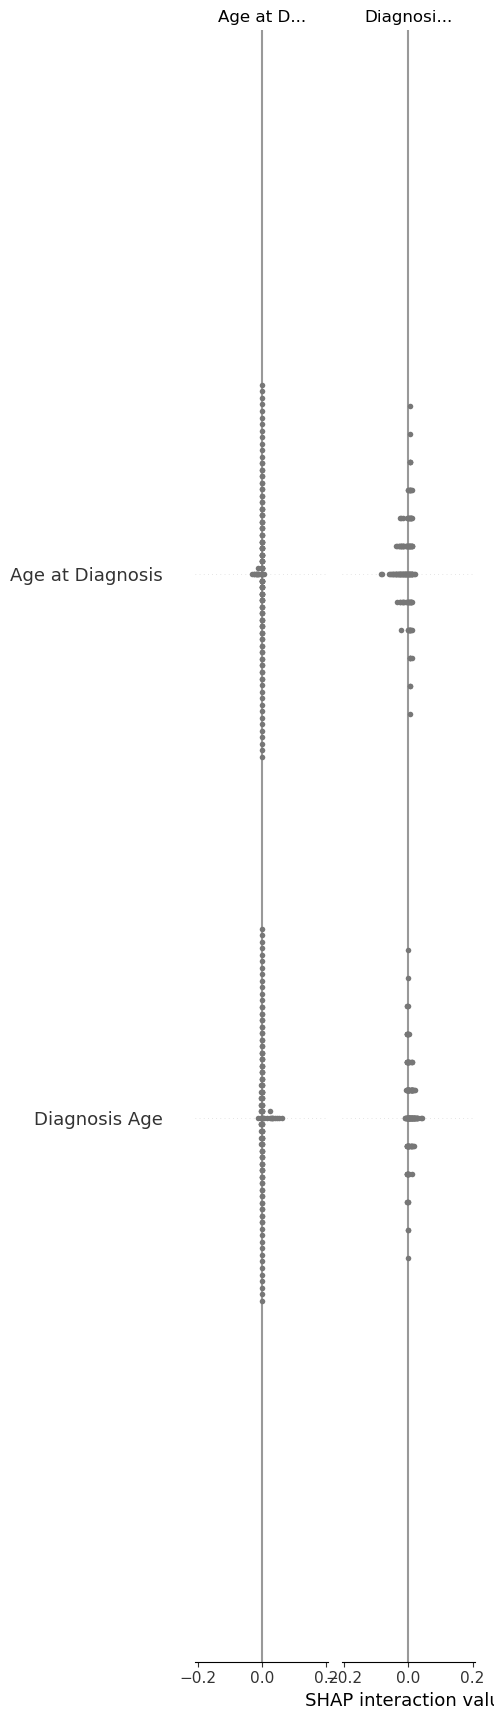

In [26]:
shap.summary_plot(sv, Xv_trans, feature_names=feature_names, plot_type="bar", max_display=20, show=True)

In [27]:
shap_values = explainer.shap_values(Xv_shap)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

In [28]:
import numpy as np
import shap

i = 0  # change this index to any validation row

# base value for class

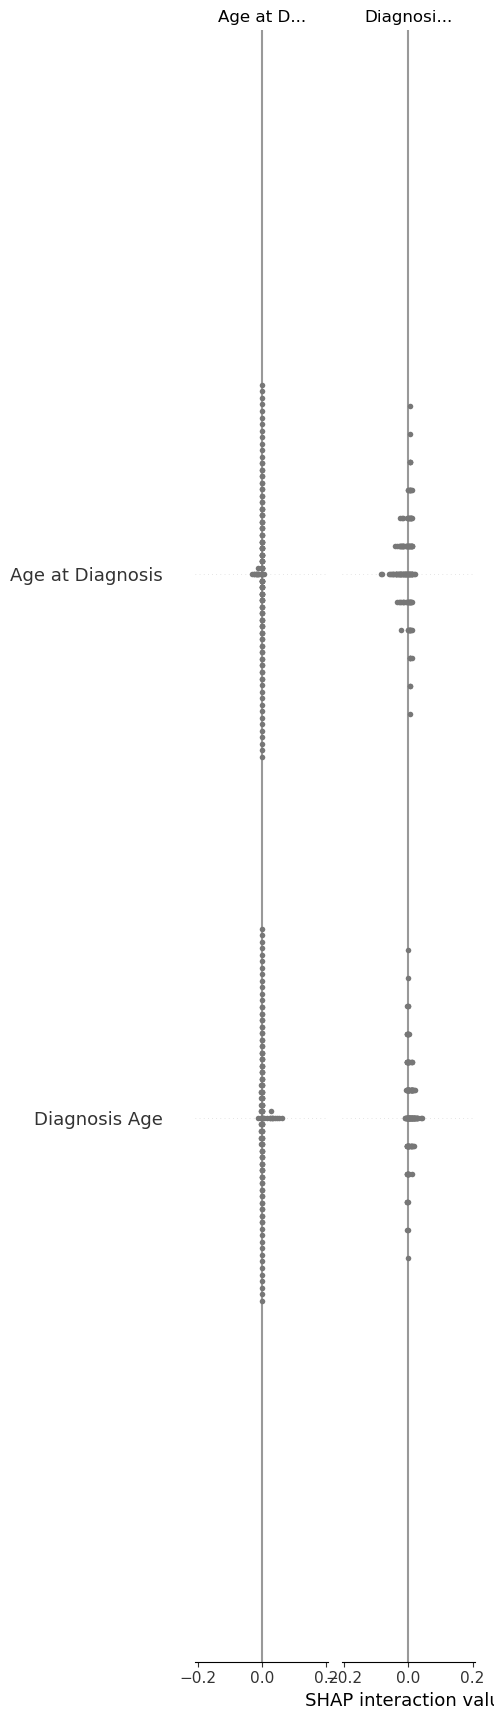

In [29]:
clean_names = [n.replace("num__", "").replace("cat__", "") for n in feature_names]
shap.summary_plot(sv, Xv_trans, feature_names=clean_names, plot_type="bar", max_display=20, show=True)

In [30]:
#PDP
from sklearn.inspection import PartialDependenceDisplay

top_num_features = X_val.select_dtypes(include=["number"]).columns[:3].tolist()
top_num_features

['Diagnosis Age',
 'Age at Diagnosis',
 'Neoplasm Disease Stage American Joint Committee on Cancer Code']

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

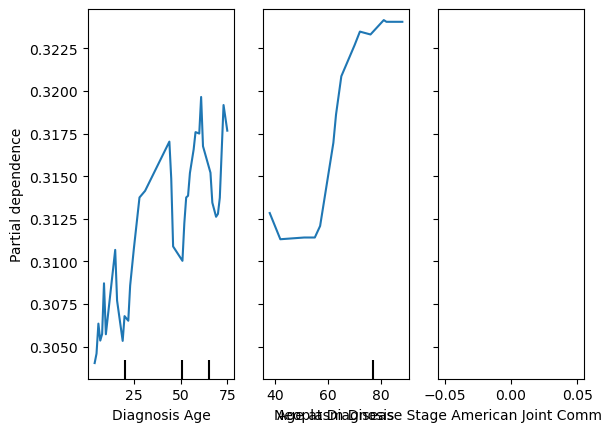

In [31]:
if len(top_num_features) > 0:
    PartialDependenceDisplay.from_estimator(best_model, X_val, features=top_num_features)
    plt.show()

In [32]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

imp = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(20)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,feature,importance_mean,importance_std
139,Progression Free Status,0.261031,0.043189
205,Patient's Vital Status,0.023271,0.002179
164,Number of Samples Per Patient,0.015437,0.005667
169,Sex,0.006479,0.004748
179,Stage (Highest Recorded),0.006250,0.004184
57,Fraction Genome Altered,0.005604,0.005459
90,IPI,0.001990,0.001027
38,Disease Free (Months),0.001917,0.000740
116,New Neoplasm Event Post Initial Therapy Indicator,0.001250,0.001752
89,In PanCan Pathway Analysis,0.001073,0.000105


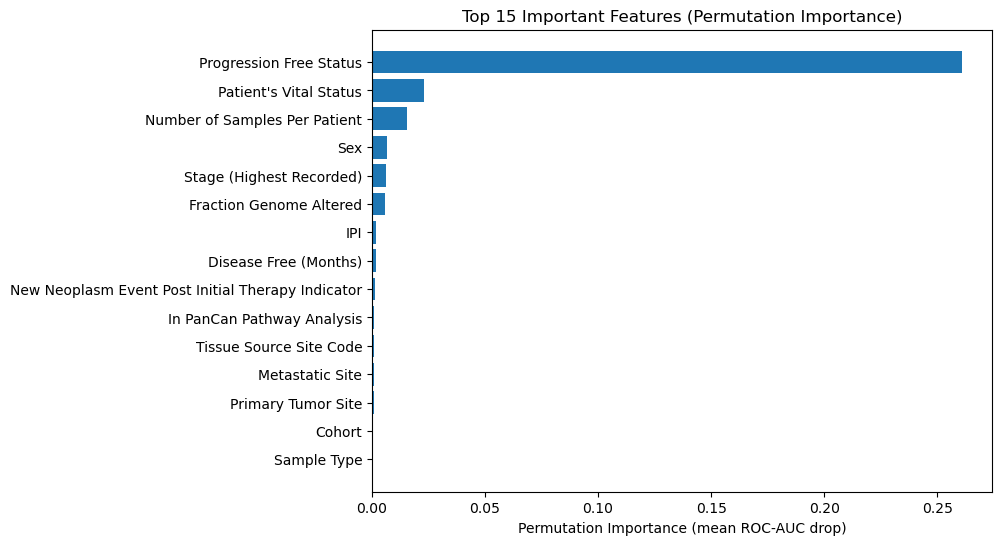

In [33]:
import matplotlib.pyplot as plt

top = imp.head(15).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["importance_mean"])
plt.xlabel("Permutation Importance (mean ROC-AUC drop)")
plt.title("Top 15 Important Features (Permutation Importance)")
plt.show()

In [34]:
plt.savefig("permutation_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [35]:
numeric_features = X_val.select_dtypes(include=["number"]).columns.tolist()
numeric_features[:10]

['Diagnosis Age',
 'Age at Diagnosis',
 'Neoplasm Disease Stage American Joint Committee on Cancer Code',
 'Cllularity based on allele frequency',
 'Aneuploidy Score',
 'BCL2 Fish Status',
 'BCL6 Fish Status',
 'B Symptoms at Diagnosis',
 'Censored',
 'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage']

In [36]:
top_features = [f for f in imp["feature"] if f in numeric_features][:3]

print("Top numeric features:", top_features)

Top numeric features: ['Number of Samples Per Patient', 'Fraction Genome Altered', 'IPI']


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 164 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 1

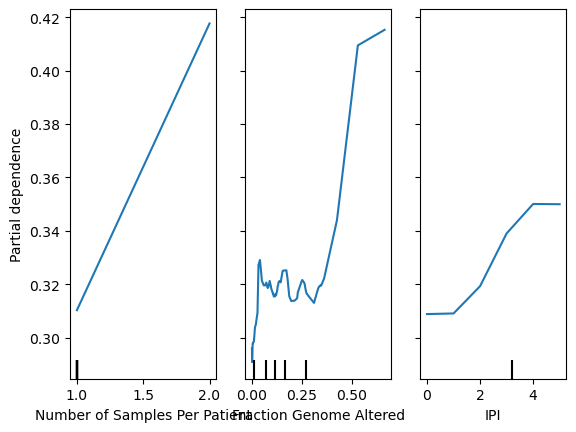

In [37]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    best_model,
    X_val,
    features=top_features
)

plt.show()

In [38]:
plt.savefig("pdp_plot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [39]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [40]:
#Final Test Set Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_proba = best_model.predict_proba(X_test)[:,1]
test_pred = (test_proba >= 0.35).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))

Accuracy: 0.772972972972973
Precision: 0.6323529411764706
Recall: 0.7166666666666667
F1: 0.671875
ROC-AUC: 0.875


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


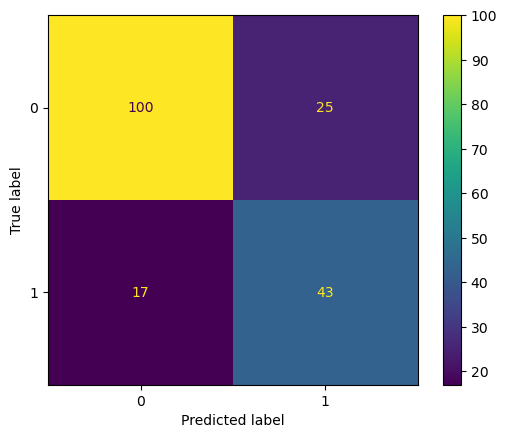

In [41]:
#Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)

In [42]:
THRESHOLD = 0.35

test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= THRESHOLD).astype(int)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [43]:
import joblib

joblib.dump({
    "model": best_model,
    "threshold": THRESHOLD
}, "final_rf_model_threshold035.pkl")

['final_rf_model_threshold035.pkl']

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


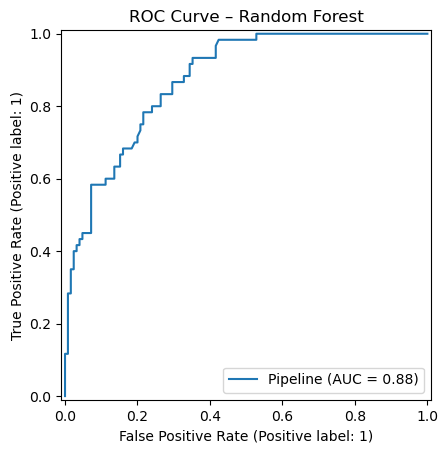

In [44]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve – Random Forest")
plt.savefig("roc_curve_rf.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


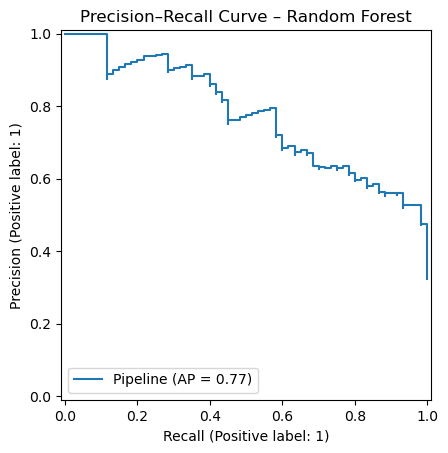

In [45]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Precision–Recall Curve – Random Forest")
plt.savefig("pr_curve_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
import pandas as pd

results = pd.DataFrame([{
    "Model": "Random Forest (threshold 0.35)",
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_proba)
}])

results.to_csv("final_model_results.csv", index=False)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (threshold 0.35),0.772973,0.632353,0.716667,0.671875,0.875


In [55]:
import numpy as np
import shap

In [48]:
feature_names_fixed = feature_names[:X_dep.shape[1]]

print("Fixed feature names length:", len(feature_names_fixed))
print("X_dep columns:", X_dep.shape[1])

Fixed feature names length: 766
X_dep columns: 766


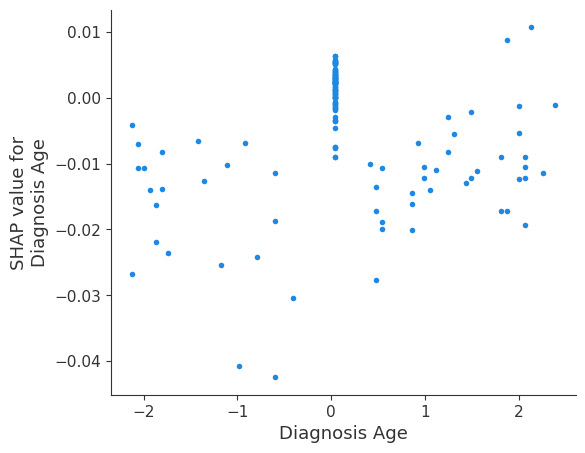

In [49]:
shap.dependence_plot(
    "Diagnosis Age",
    sv_dep,
    X_dep,
    feature_names=feature_names_fixed,
    interaction_index=None
)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


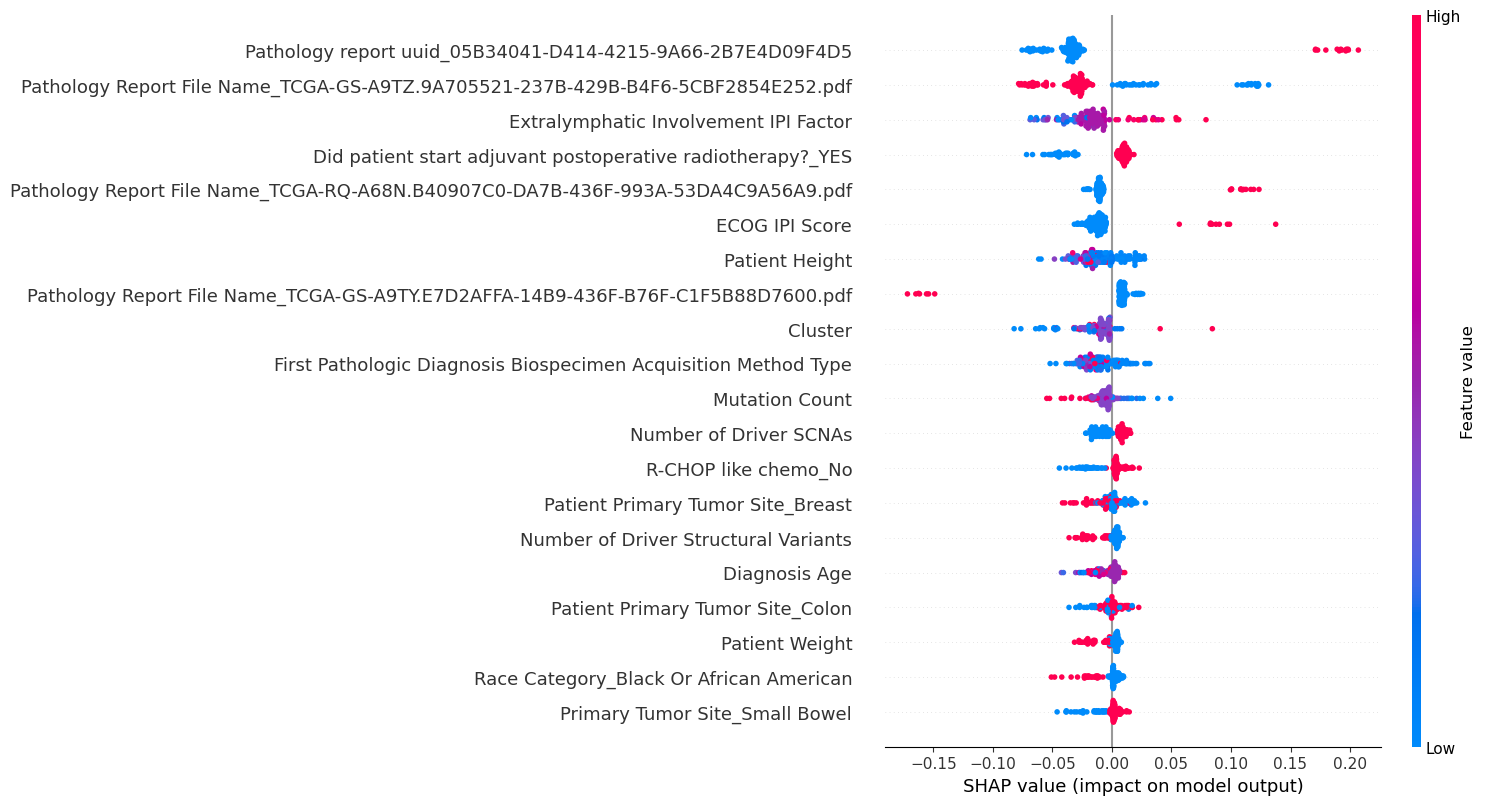

In [50]:
shap.summary_plot(sv_dep, X_dep, feature_names=feature_names_fixed)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


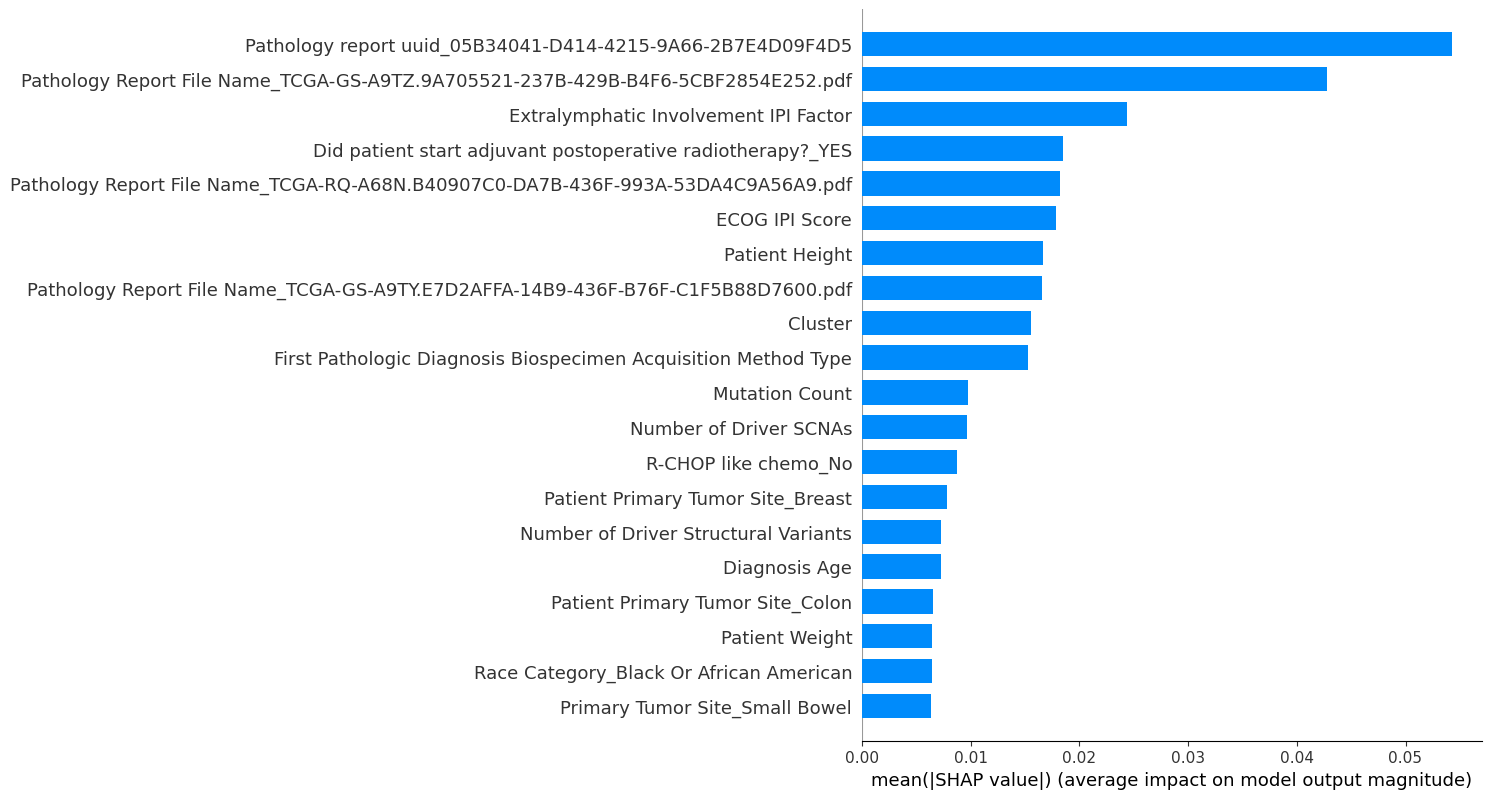

In [53]:
shap.summary_plot(sv_dep, X_dep, feature_names=feature_names_fixed, plot_type="bar", max_display=20)

In [54]:
plt.savefig("shap_dependence_diagnosis_age.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
import pandas as pd

def eval_model(model, X, y, threshold=0.35, name="model"):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)

    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
        "brier": brier_score_loss(y, proba)
    }

comparison = pd.DataFrame([
    eval_model(best_model, X_test, y_test, 0.35, "RF original"),
    eval_model(cal_sigmoid, X_test, y_test, 0.35, "RF calibrated sigmoid"),
    eval_model(cal_isotonic, X_test, y_test, 0.35, "RF calibrated isotonic"),
])

comparison

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 9

,model,accuracy,precision,recall,f1,roc_auc,brier
0,RF original,0.772973,0.632353,0.716667,0.671875,0.875000,0.138304
1,RF calibrated sigmoid,0.794595,0.666667,0.733333,0.698413,0.878133,0.137778
2,RF calibrated isotonic,0.762162,0.614286,0.716667,0.661538,0.866733,0.139437


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 9

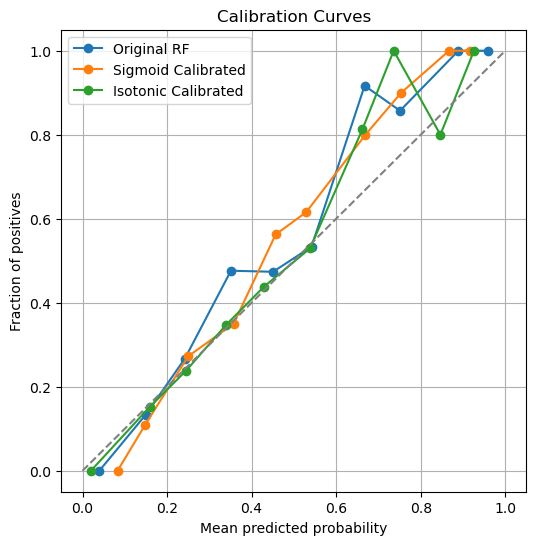

In [58]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

models = {
    "Original RF": best_model,
    "Sigmoid Calibrated": cal_sigmoid,
    "Isotonic Calibrated": cal_isotonic
}

plt.figure(figsize=(6,6))

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curves")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


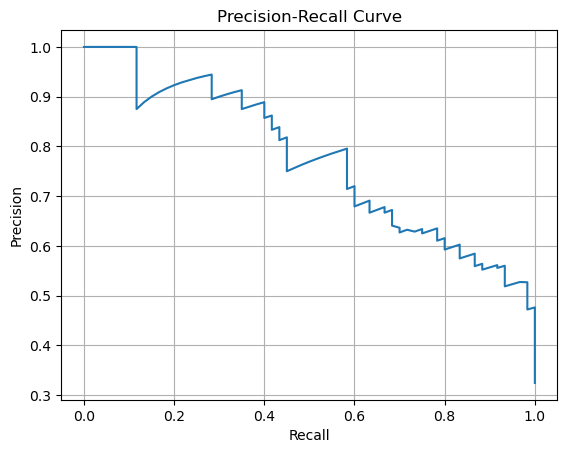

In [59]:
#Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

proba = best_model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()